# Remove zero stripe at -180 longitude from iceberg calving input file

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean
import xesmf as xe
import gsw
from scipy import ndimage

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(threads_per_worker = 1, memory_limit="12GB")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 312.92 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42341,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37493,Total threads: 1
Dashboard: /proxy/34789/status,Memory: 11.18 GiB
Nanny: tcp://127.0.0.1:37525,


## Importing original iceberg input data

This file was originally made by this script: https://github.com/ACCESS-NRI/om3-scripts/blob/main/rof_pattern_generation/generate_rofi_pattern.py

In [135]:
iceberg_path = '/g/data/x77/cy8964/mom6/input/input-8km/17.06.26/rofi_spread_Bgrid_non_advective.nc'
iceberg_data = xr.open_dataset(iceberg_path).pattern_Forr_rofi

In [87]:
# create mask to move flux from cavities to ocean:

# sea ice topography:
topog_seaice_path = '/g/data/x77/cy8964/mom6/input/input-8km/17.06.26/topog_seaice.nc'
topog_seaice = xr.open_dataset(topog_seaice_path)
seaice_mask = topog_seaice.depth.where(topog_seaice.depth==0,other=1)
#seaice_mask.plot()

# set land to True, ocean to False and match dimensions names to iceberg data:
land = (seaice_mask == 0).rename({"ny": "rof_ny", "nx": "rof_nx"})
#land = land.transpose("rof_ny", "rof_nx")
land_np = land.values.astype(bool)
ocean_np = ~land_np

ny, nx = land_np.shape
ncell = ny * nx

In [88]:
# Need to multiply by area so we get conservation correct:

area_path = '/g/data/ik11/outputs/access-rom3-panan/MC_4km_jra_iaf+regionalpanan+isf/output000/access-om3.mom6.static.nc'
areacello = xr.open_dataset(area_path).areacello

# match dimensions names to iceberg data and get rid of coordinates so it matches iceberg data:
area_tmp = areacello.rename({"yh": "rof_ny","xh": "rof_nx"})#.transpose("rof_ny", "rof_nx")
area_rof = xr.DataArray(
    area_tmp.values,
    dims=("rof_ny", "rof_nx"),
    attrs=area_tmp.attrs,
    name=area_tmp.name
)

iceberg_data_area = iceberg_data*area_rof

In [89]:
# Precompute the nearest ocean cell for each land cell, with longitude wrapping:
    
# Repeat in x so nearest-ocean search wraps around longitude
land_3x = np.concatenate([land_np, land_np, land_np], axis=1)

_, nearest_idx = ndimage.distance_transform_edt(
    land_3x,
    return_indices=True
)

# Pull out the central longitude copy
iy_nearest = nearest_idx[0][:, nx:2*nx]
ix_nearest = nearest_idx[1][:, nx:2*nx] % nx

land_indices = np.flatnonzero(land_np.ravel())

target_indices = np.ravel_multi_index(
    (iy_nearest.ravel(), ix_nearest.ravel()),
    dims=(ny, nx)
)

land_targets = target_indices[land_indices]

In [90]:
# define function that smooths the original data before moving from land to ocean:

def smooth_field_gaussian(field, sigma_y=2, sigma_x=8):
    """
    Smooth the original 2D field with an anisotropic Gaussian filter.

    sigma_y and sigma_x are in grid points.
    Longitude wraps; latitude does not.
    """

    total_in = np.nansum(field)

    field = np.nan_to_num(field, nan=0.0)

    smooth = ndimage.gaussian_filter(
        field,
        sigma=(sigma_y, sigma_x),
        mode=("constant", "wrap"),
        cval=0.0,
        truncate=4.0
    )

    total_out = np.nansum(smooth)

    if total_out > 0:
        smooth = smooth * (total_in / total_out)

    return smooth

In [91]:
# Now define the spreading function. Here spread_x=50 means a 50-grid-point boxcar filter 
# in longitude, and spread_y=10 means a 10-grid-point boxcar filter in latitude.

def spread_ocean_only_gaussian(field, sigma_y=2, sigma_x=8):
    """
    Spread a 2D field using a Gaussian filter, then keep only ocean values
    and renormalise to conserve total flux.
    """

    total_in = np.nansum(field)

    if total_in == 0:
        return field

    field = np.nan_to_num(field, nan=0.0)

    spread = ndimage.gaussian_filter(
        field,
        sigma=(sigma_y, sigma_x),
        mode=("constant", "wrap"),
        cval=0.0,
        truncate=4.0
    )

    spread = np.where(ocean_np, spread, 0.0)

    total_out = np.nansum(spread)

    if total_out > 0:
        spread = spread * (total_in / total_out)
    else:
        spread = field

    return spread

In [92]:
# Function to apply this to each time step of iceberg data:

def move_land_flux_to_spread_ocean(
    arr2d,
    sigma_y=2,
    sigma_x=8,
    smooth_original=True
):
    """
    Smooth the original field, then move flux from land to nearest ocean cells,
    then spread that transferred flux with a Gaussian filter.
    """

    arr2d = np.asarray(arr2d)

    # Smooth the original iceberg field first
    if smooth_original:
        arr2d = smooth_field_gaussian(
            arr2d,
            sigma_y=sigma_y,
            sigma_x=sigma_x
        )

    arr_flat = arr2d.ravel()

    # Keep smoothed ocean flux only
    ocean_flux_flat = arr_flat.copy()
    ocean_flux_flat[land_indices] = 0.0

    # Extract smoothed flux that is still on land
    land_flux = np.nan_to_num(arr_flat[land_indices], nan=0.0)

    # Deposit land flux onto nearest ocean cells
    coastal_added_flat = np.bincount(
        land_targets,
        weights=land_flux,
        minlength=ncell
    )

    coastal_added = coastal_added_flat.reshape((ny, nx))

    # Smooth/spread the transferred land flux over nearby ocean cells
    spread_added = spread_ocean_only_gaussian(
        coastal_added,
        sigma_y=sigma_y,
        sigma_x=sigma_x
    )

    fixed = ocean_flux_flat.reshape((ny, nx)) + spread_added

    # Make sure land remains zero
    fixed = np.where(ocean_np, fixed, 0.0)

    return fixed

In [93]:
# Apply moving flux in cavities to open ocean and spread it:

fixed_slices = []

for t in range(iceberg_data.sizes["time"]):
    fixed_2d = move_land_flux_to_spread_ocean(
        iceberg_data_area.isel(time=t).values,
        sigma_y=10,
        sigma_x=40,
        smooth_original=True
    )

    fixed_slices.append(
        xr.DataArray(
            fixed_2d,
            dims=("rof_ny", "rof_nx"),
            coords={
                "rof_ny": iceberg_data["rof_ny"] if "rof_ny" in iceberg_data.coords else np.arange(ny),
                "rof_nx": iceberg_data["rof_nx"] if "rof_nx" in iceberg_data.coords else np.arange(nx),
            }
        )
    )

fixed_iceberg_data = xr.concat(
    fixed_slices,
    dim=iceberg_data["time"]
)

fixed_iceberg_data.name = iceberg_data.name
fixed_iceberg_data.attrs = iceberg_data.attrs

# divide out by area:
fixed_iceberg_data = fixed_iceberg_data/area_rof

In [94]:
original_total = iceberg_data.sum(("rof_ny", "rof_nx"))
fixed_total = fixed_iceberg_data.sum(("rof_ny", "rof_nx"))

fixed_land_total = fixed_iceberg_data.where(land).sum(("rof_ny", "rof_nx"))

print("Flux remaining on land:")
print(fixed_land_total.values)

print("Maximum absolute conservation error:")
print(np.abs(fixed_total - original_total).max().values)

Flux remaining on land:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Maximum absolute conservation error:
4.245428726044601e-10


In [132]:
# Fill NaNs in fixed iceberg data (these are only over land):
fixed_iceberg_data = fixed_iceberg_data.fillna(0)

In [133]:
## Save, writing over existing initial conditions variables to make sure we get correct metadata etc:

# file to overwrite variables:
iceberg_file2 = '/g/data/g40/akm157/inputs/mom6/om3_panan_ice_shelf/rofi_spread_Bgrid_non_advective.nc'

# then overwrite the variables with the new data:
ncFile = nc.Dataset(iceberg_file2,'r+')
ncFile.variables['pattern_Forr_rofi'][...] = fixed_iceberg_data.values
ncFile.close()

## Plot to compare old and new iceberg input data:

In [27]:
# import topography for masking:

# ice shelf cavity topography:
topog_path = '/g/data/x77/cy8964/mom6/input/input-8km/22.06.26/topog.nc'
topog = xr.open_dataset(topog_path)

land_mask = topog.depth.where(topog.depth==0)

# sea ice topography:
topog_seaice_path = '/g/data/x77/cy8964/mom6/input/input-8km/17.06.26/topog_seaice.nc'
topog_seaice = xr.open_dataset(topog_seaice_path)

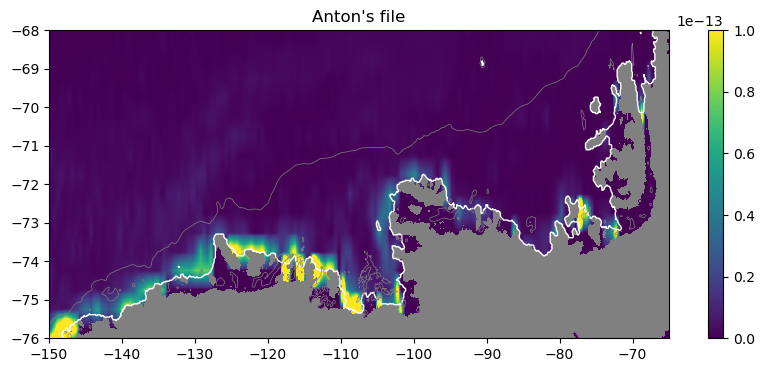

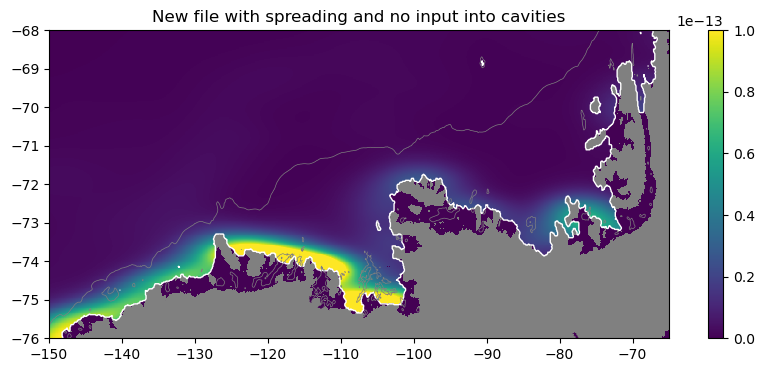

In [120]:
# plot zoom on Amundsen to see how patchy it is:

# original data:

month = 0
pattern_Forr_rofi = iceberg_data.isel(time=month)

plt.figure(figsize=(10,4))
plt.pcolormesh(topog.lon, topog.lat,pattern_Forr_rofi,vmin=0,vmax=1e-13)
plt.colorbar()

plt.contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='w',linewidths=1)
plt.contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='gray',linewidths=0.5)

from matplotlib.colors import ListedColormap
solid_grey_cmap = ListedColormap(['grey']) 
plt.pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)

plt.xlim(-150,-65)
plt.ylim(-76,-68)
plt.title("Anton's file");

###############
# 'fixed' data:

month = 0
pattern_Forr_rofi = fixed_iceberg_data.isel(time=month)

plt.figure(figsize=(10,4))
plt.pcolormesh(topog.lon, topog.lat,pattern_Forr_rofi,vmin=0,vmax=1e-13)
plt.colorbar()

plt.contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='w',linewidths=1)
plt.contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='gray',linewidths=0.5)

plt.pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)

plt.xlim(-150,-65)
plt.ylim(-76,-68)
plt.title('New file with spreading and no input into cavities');

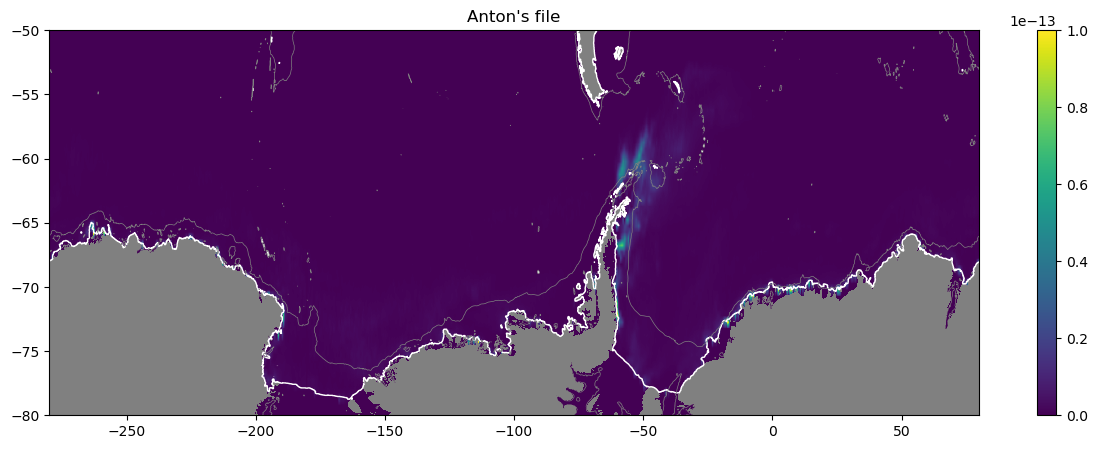

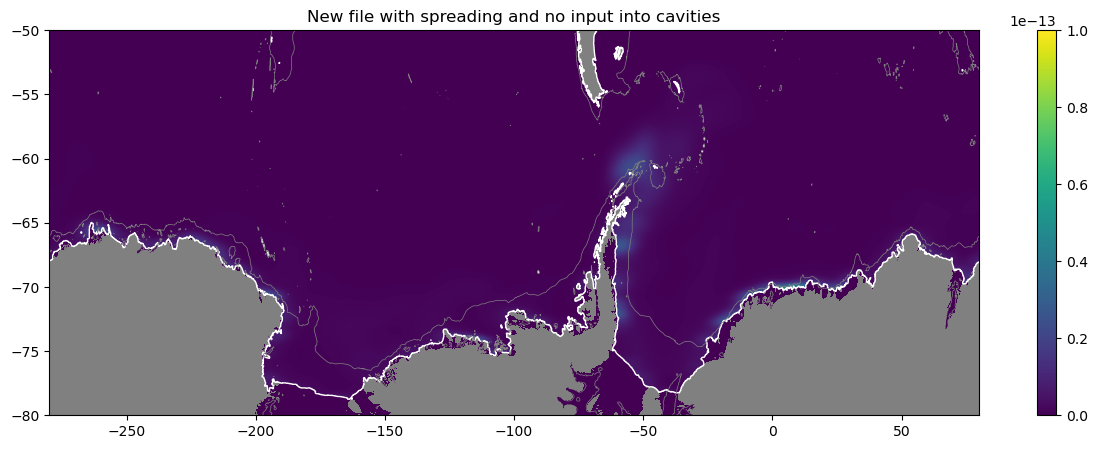

In [126]:
# plot whole domain:
month = 9

# Anton's original file:
pattern_Forr_rofi = iceberg_data.isel(time=month)

plt.figure(figsize=(15,5))
plt.pcolormesh(topog.lon, topog.lat,pattern_Forr_rofi,vmin=0,vmax=1e-13)
plt.colorbar()

plt.contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='w',linewidths=1)
plt.contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='gray',linewidths=0.5)

plt.pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)

plt.title("Anton's file");
plt.ylim(-80,-50)

##################
# 'fixed' data:

pattern_Forr_rofi = fixed_iceberg_data.isel(time=month)

plt.figure(figsize=(15,5))
plt.pcolormesh(topog.lon, topog.lat,pattern_Forr_rofi,vmin=0,vmax=1e-13)
plt.colorbar()

plt.contour(topog.lon, topog.lat, topog_seaice.depth, levels=[0], colors='w',linewidths=1)
plt.contour(topog.lon, topog.lat, topog.depth, levels=[1000], colors='gray',linewidths=0.5)

plt.pcolormesh(topog.lon,topog.lat,land_mask,cmap=solid_grey_cmap)
plt.ylim(-80,-50)
plt.title('New file with spreading and no input into cavities');

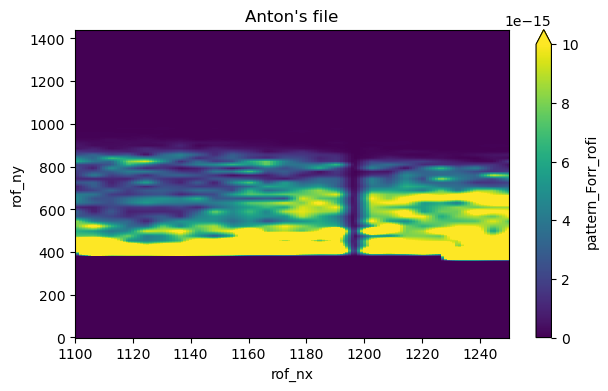

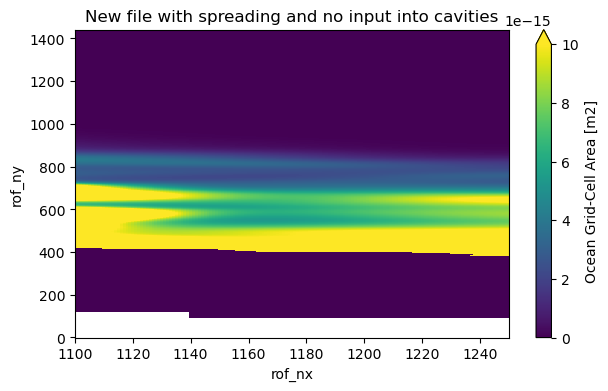

In [124]:
# Check that stripe is no longer a problem, this should be fixed from the smoothing already done:

month = 0
pattern_Forr_rofi = iceberg_data.isel(time=month)

plt.figure(figsize=(7,4))
pattern_Forr_rofi.plot(vmin=0,vmax=1e-14)
plt.xlim(1100,1250)
plt.title("Anton's file");

plt.figure(figsize=(7,4))
fixed_iceberg_data.isel(time=month).plot(vmin=0,vmax=1e-14)
plt.xlim(1100,1250)
plt.title('New file with spreading and no input into cavities');